In [1]:
import pandas as pd

In [2]:
df_airbnb = pd.read_csv("../raw_dataset/Buenos_Aires_AIRBNB.csv")

In [3]:
df_airbnb.head()

,id,name,host_id,host_name,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,7270,¡¡Great Loft in Palermo Hollywood!!,18822,Toni,Palermo,-34.58241,-58.43382,Entire home/apt,2033,20,14,30-04-2018,0.15,1,363
1,11508,Amazing Luxurious Apt-Palermo Soho,42762,Candela,Palermo,-34.58225,-58.42460,Entire home/apt,3588,2,25,13-08-2019,0.28,1,281
2,12463,Room in Recoleta - awesome location,48799,Matt,Recoleta,-34.59761,-58.39468,Private room,1435,1,20,11-12-2017,0.17,1,365
3,13095,Standard Room at Palermo Viejo B&B,50994,Ariel,Palermo,-34.59382,-58.42994,Private room,2691,1,1,18-12-2018,0.09,7,360
4,13096,Standard Room in Palermo Viejo B&B,50994,Ariel,Palermo,-34.59398,-58.42853,Private room,2691,1,0,NaN,NaN,7,360


In [4]:
df_airbnb.columns

Index(['id', 'name', 'host_id', 'host_name', 'neighbourhood', 'latitude',
       'longitude', 'room_type', 'price', 'minimum_nights',
       'number_of_reviews', 'last_review', 'reviews_per_month',
       'calculated_host_listings_count', 'availability_365'],
      dtype='object')

In [5]:
# Nulos por columnas: 
df_airbnb.isnull().sum()

id                                   0
name                                10
host_id                              0
host_name                           23
neighbourhood                        0
latitude                             0
longitude                            0
room_type                            0
price                                0
minimum_nights                       0
number_of_reviews                    0
last_review                       6445
reviews_per_month                 6445
calculated_host_listings_count       0
availability_365                     0
dtype: int64

In [6]:
df_airbnb.shape

(22877, 15)

In [7]:
#Verifico el formato de la columna "price"
df_airbnb["price"].dtype

dtype('int64')

In [8]:
df_airbnb["price"].head(10)

0    2033
1    3588
2    1435
3    2691
4    2691
5    2691
6    3588
7    4185
8    4185
9    3588
Name: price, dtype: int64

In [9]:
df_airbnb["price"].unique()

array([  2033,   3588,   1435,   2691,   4185,   3887,   2332,   7175,
         1794,   2093,   2990,  20927,   5381,  10763,   2511,   3528,
         2392,   1913,   2930,   3289,   3767,   4664,   2272,   4484,
         4783,   5082,   7653,   2212,   7474,   1614,   6577,   7773,
         5262,   3049,   4425,  22721,  21645,  13154,   2870,   2571,
         3707,   2810,   1375,   5979,   1315,    837,   1256,    538,
         3468,   1016,   1674,   1076,   2153,   6637,   9567,  23857,
         1555,  29896,   1495,   3229,   1196,   9268,   9208,   3946,
          658,    598,   5322,   4126,   6996,   3348,   8371,   5919,
         3169,   7713,  12556,   4724,  53096,  27744,  36115,  12257,
        10165,   5860,   2750,   1973,   6278,  17938,    957,   4066,
          718,   1734,   3408,   3109,  14948,  59792,  17579,    897,
         5680,   8969,   1136,   4963,   4006,   1854,  59972,  11958,
        38865,  19134,   5620,   6876,   2631,    299,  10464,   2451,
      

In [10]:
df_airbnb["price"].dtype
df_airbnb["price"].isnull().sum()
df_airbnb["price"].describe()

count     22877.000000
mean       3214.630196
std       12364.429880
min         120.000000
25%        1196.000000
50%        1973.000000
75%        2990.000000
max      597865.000000
Name: price, dtype: float64

In [11]:
# Los precios están bastante dispersos, con valores que se alejan mucho del promedio.

In [12]:
df_airbnb["price"].quantile([0.01, 0.25, 0.5, 0.75, 0.99])

0.01      359.0
0.25     1196.0
0.50     1973.0
0.75     2990.0
0.99    17938.0
Name: price, dtype: float64

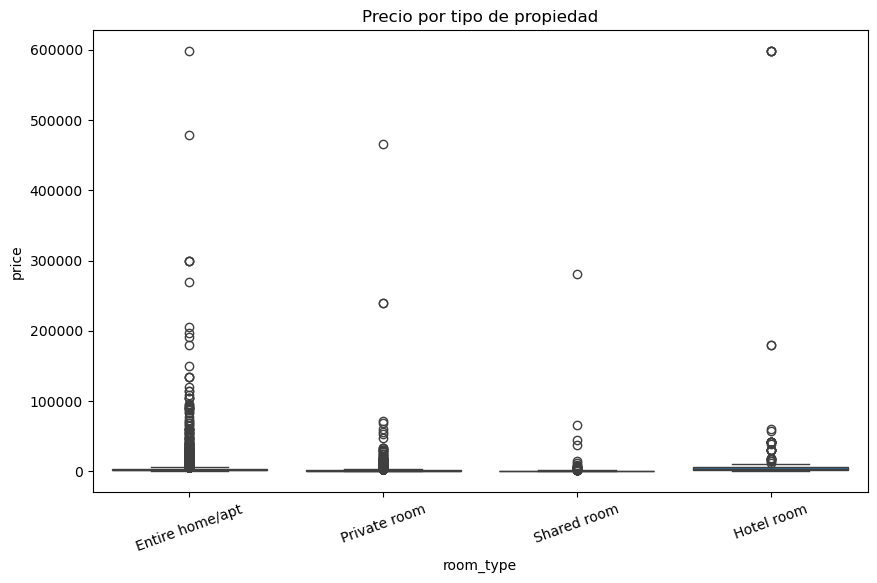

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.boxplot(x="room_type", y="price", data=df_airbnb)
plt.xticks(rotation=20)
plt.title("Precio por tipo de propiedad")
plt.show()

In [14]:
# Se observan valores de precio elevados en todos los tipos de propiedad.

In [15]:
#df_airbnb["room_type"].value_counts()

In [16]:
df_airbnb.groupby("room_type")["price"].describe()

,count,mean,std,min,25%,50%,75%,max
room_type,,,,,,,,
Entire home/apt,17389.0,3437.318707,9353.533493,179.0,1614.0,2332.0,3468.0,597865.0
Hotel room,345.0,13464.220290,65356.266156,239.0,1734.0,3109.0,5680.0,597865.0
Private room,4598.0,1781.497173,9001.490875,120.0,658.0,957.0,1495.0,466501.0
Shared room,545.0,1712.073394,12600.692570,179.0,478.0,598.0,897.0,281025.0


Se observan valores extremadamente altos en la categoría “Shared room”, lo cual resulta inconsistente con el comportamiento esperado 
de este tipo de alojamiento y sugiere la posible presencia de errores o registros atípicos.

Tambien hay una fuerte diferencia entre la media y la mediana, lo que indica una distribución sesgada por valores extremos.
En este contexto, la mediana representa mejor el precio típico de los alojamientos.

### Relacionamos los precios promedios por vecindario:

In [17]:
df_airbnb.groupby("neighbourhood")["price"].mean().sort_values(ascending=False)

neighbourhood
Villa Gral. Mitre    9119.216216
Puerto Madero        8991.506173
Villa Santa Rita     8223.235294
Monserrat            5102.353620
Monte Castro         4287.625000
Retiro               3838.940466
Constitucion         3625.800000
Palermo              3625.333862
Villa Soldati        3527.666667
Saavedra             3413.449664
Recoleta             3313.809330
San Telmo            3054.037572
Belgrano             2761.555344
San Cristobal        2704.412162
Colegiales           2676.238095
San Nicolas          2662.625380
Barracas             2639.930636
Villa Devoto         2573.602740
Nuñez                2370.181604
Villa Crespo         2353.618182
Chacarita            2312.007042
Balvanera            2288.083636
Nueva Pompeya        2287.000000
Villa Urquiza        2189.317269
Versalles            2122.700000
Almagro              2120.447395
Velez Sarsfield      2115.944444
Coghlan              2080.666667
Boedo                2080.017699
Liniers              1925.300

In [18]:
df_airbnb["neighbourhood"].value_counts().head(10)

neighbourhood
Palermo         6934
Recoleta        3687
San Nicolas     1316
Retiro          1159
Balvanera       1100
Belgrano        1048
Almagro          979
Monserrat        953
Villa Crespo     770
San Telmo        692
Name: count, dtype: int64

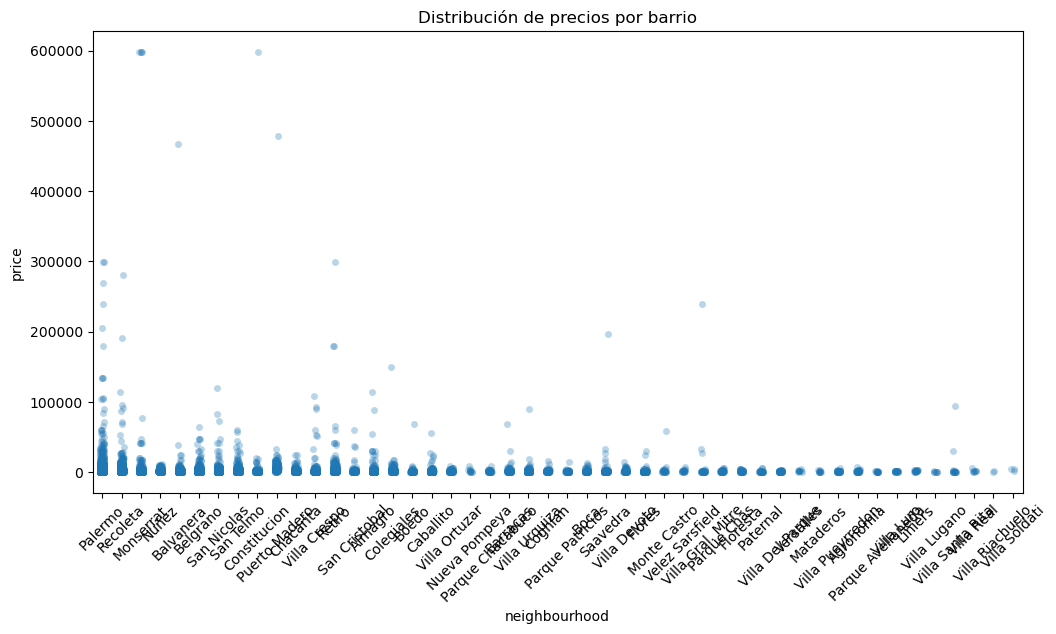

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
sns.stripplot(x="neighbourhood", y="price", data=df_airbnb, jitter=True, alpha=0.3)
plt.xticks(rotation=45)
plt.title("Distribución de precios por barrio")
plt.show()

Se observan valores de precio significativamente más altos que el resto de la distribución. Sin embargo, dado que los precios están expresados en pesos argentinos, estos valores podrían corresponder a propiedades premium o alojamientos de alta categoría.

Los barrios más caros se concentran en zonas como San Telmo y Recoleta, lo cual es coherente con su alta demanda y ubicación.
Sin embargo, la ausencia de variables como metros cuadrados limita una interpretación más precisa del precio.

### Columna "reviews_per_month " : La variable reviews_per_month representa la frecuencia promedio de reseñas que recibe cada alojamiento por mes.

In [20]:
df_airbnb["reviews_per_month"].dtype

dtype('float64')

In [21]:
df_airbnb["reviews_per_month"].unique

<bound method Series.unique of 0        0.15
1        0.28
2        0.17
3        0.09
4         NaN
         ... 
22872     NaN
22873     NaN
22874     NaN
22875     NaN
22876     NaN
Name: reviews_per_month, Length: 22877, dtype: float64>

In [22]:
df_airbnb["reviews_per_month"].describe()

count    16432.000000
mean         1.266434
std          1.440429
min          0.010000
25%          0.250000
50%          0.760000
75%          1.810000
max         37.580000
Name: reviews_per_month, dtype: float64

Se identifican valores nulos en la variable reviews_per_month, los cuales se interpretan como ausencia de actividad o falta de registros de reseñas. Para el análisis, se imputan con 0 con el objetivo de facilitar su tratamiento y visualización a continuación:

In [23]:
df_airbnb["reviews_per_month"] = df_airbnb["reviews_per_month"].fillna(0)

In [24]:
df_airbnb["reviews_per_month"].isnull().sum()

0

### Columna "room type":

In [25]:
df_airbnb["room_type"].dtype

dtype('O')

In [26]:
df_airbnb["room_type"].unique()

array(['Entire home/apt', 'Private room', 'Shared room', 'Hotel room'],
      dtype=object)

In [27]:
df_airbnb["room_type"].value_counts()

room_type
Entire home/apt    17389
Private room        4598
Shared room          545
Hotel room           345
Name: count, dtype: int64

La variable room_type tiene 4 categorías y no presenta valores nulos. También se observa que “Entire home/apt” es el tipo de alojamiento más frecuente dentro del dataset.

### Columna "neighbourhood"

In [28]:
df_airbnb["neighbourhood"].dtype    

dtype('O')

In [29]:
df_airbnb["neighbourhood"].isnull().sum()

0

In [30]:
df_airbnb["neighbourhood"].unique()

array(['Palermo', 'Recoleta', 'Monserrat', 'Nuñez', 'Balvanera',
       'Belgrano', 'San Nicolas', 'San Telmo', 'Constitucion',
       'Puerto Madero', 'Chacarita', 'Villa Crespo', 'Retiro',
       'San Cristobal', 'Almagro', 'Colegiales', 'Boedo', 'Caballito',
       'Villa Ortuzar', 'Nueva Pompeya', 'Parque Chacabuco', 'Barracas',
       'Villa Urquiza', 'Coghlan', 'Parque Patricios', 'Boca', 'Saavedra',
       'Villa Devoto', 'Flores', 'Monte Castro', 'Velez Sarsfield',
       'Villa Gral. Mitre', 'Parque Chas', 'Floresta', 'Paternal',
       'Villa Del Parque', 'Versalles', 'Mataderos', 'Villa Pueyrredon',
       'Agronomia', 'Parque Avellaneda', 'Villa Luro', 'Liniers',
       'Villa Lugano', 'Villa Santa Rita', 'Villa Real',
       'Villa Riachuelo', 'Villa Soldati'], dtype=object)

In [31]:
df_airbnb["neighbourhood"].value_counts()

neighbourhood
Palermo              6934
Recoleta             3687
San Nicolas          1316
Retiro               1159
Balvanera            1100
Belgrano             1048
Almagro               979
Monserrat             953
Villa Crespo          770
San Telmo             692
Colegiales            462
Caballito             459
Chacarita             426
Nuñez                 424
Constitucion          335
Villa Urquiza         249
Puerto Madero         243
Barracas              173
Saavedra              149
San Cristobal         148
Boca                  119
Flores                113
Boedo                 113
Coghlan                93
Villa Ortuzar          90
Villa Devoto           73
Parque Patricios       66
Villa Del Parque       54
Parque Chas            52
Parque Chacabuco       47
Villa Pueyrredon       42
Floresta               40
Villa Gral. Mitre      37
Agronomia              36
Paternal               31
Monte Castro           24
Liniers                20
Villa Luro             1

La variable neighbourhood fue analizada verificando su tipo de dato, valores nulos y cantidad de categorías. También se observó la distribución de alojamientos por barrio utilizando value_counts(). <br>
<b> Palermo, Recoleta y San Nicolás son los barrios con mayor cantidad de alojamientos disponibles dentro del dataset. </b>

### Columna "number_of_reviews" , "minimum_nights" y "availability_365"

In [32]:
df_airbnb["number_of_reviews"].dtype

dtype('int64')

In [33]:
df_airbnb["number_of_reviews"].describe()

count    22877.000000
mean        15.482974
std         31.268565
min          0.000000
25%          0.000000
50%          4.000000
75%         16.000000
max        600.000000
Name: number_of_reviews, dtype: float64

In [34]:
(df_airbnb["number_of_reviews"] < 0).sum()

0

El 25% tiene 0 , la mediana es 4. Indica baja actividad en gran parte del dataset. <br>
La mayoría de los alojamientos presentan una baja cantidad de reseñas. Además, la diferencia entre la media y la desviación estándar sugiere una alta dispersión en los datos, influenciada por algunos alojamientos con gran cantidad de reviews.

In [35]:
df_airbnb["minimum_nights"].dtype

dtype('int64')

In [36]:
(df_airbnb["minimum_nights"] < 0).sum()

0

In [37]:
df_airbnb["minimum_nights"].describe()

count    22877.000000
mean         5.653233
std         21.513176
min          1.000000
25%          1.000000
50%          3.000000
75%          4.000000
max       1125.000000
Name: minimum_nights, dtype: float64

El 75% de los alojamientos pide como máximo 4 noches mínimas. La mediana es de 3 noches. <br>
<b> Airbnb en Buenos Aires está principalmente orientado a estadías cortas. </b>

In [38]:
df_airbnb["availability_365"].dtype

dtype('int64')

In [39]:
df_airbnb["availability_365"].isnull().sum()

0

In [40]:
df_airbnb["availability_365"].describe()

count    22877.000000
mean       202.064912
std        134.161675
min          0.000000
25%         83.000000
50%        180.000000
75%        343.000000
max        365.000000
Name: availability_365, dtype: float64

In [41]:
df_airbnb[
    (df_airbnb["availability_365"] < 0) |
    (df_airbnb["availability_365"] > 365)
]

,id,name,host_id,host_name,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365


La variable availability_365 no presenta valores fuera del rango esperado entre 0 y 365 días.

## Mapa de correlación

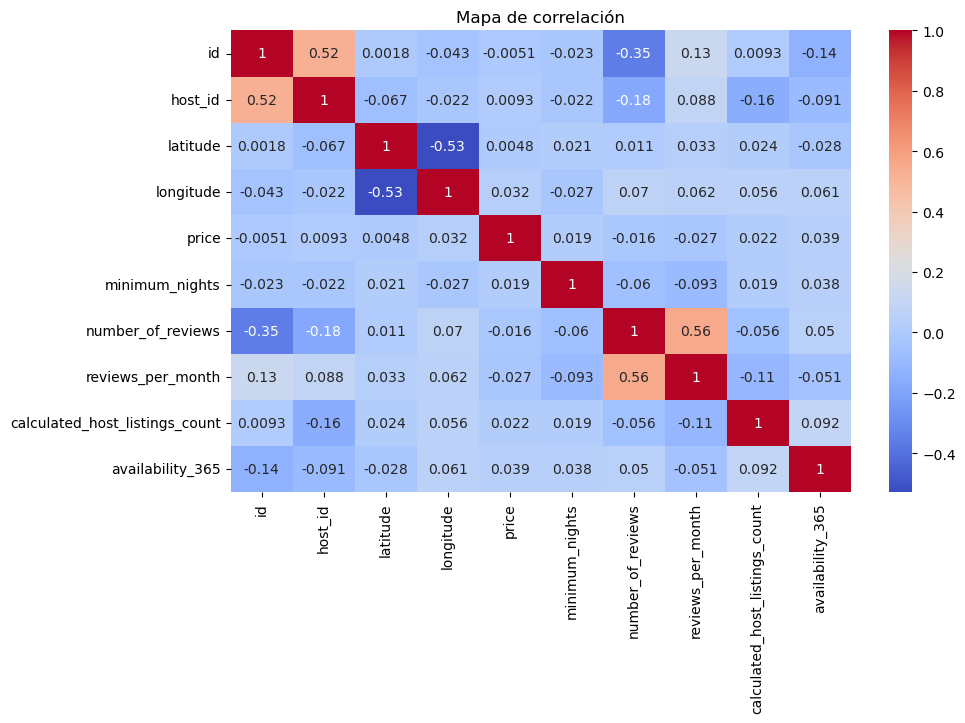

In [42]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = df_airbnb.select_dtypes(include="number").corr()

plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Mapa de correlación")
plt.show()

In [43]:
from pathlib import Path

output_dir = Path("../processed_dataset")
output_dir.mkdir(parents=True, exist_ok=True)

# Guardo dataset procesado
df_airbnb.to_csv(output_dir / "airbnb_processed.csv", index=False)

In [ ]:
import pandas as pd
import sqlite3

df = pd.read_csv("../processed_dataset/airbnb_processed.csv")

# Creo base SQLite
conn = sqlite3.connect("../airbnb.db")

# Creo tabla
df.to_sql(
    "airbnb",
    conn,
    if_exists="replace",
    index=False
)

conn.close()

print("Base creada")

Base creada correctamente


In [ ]:
import os
print(os.path.abspath("airbnb.db"))

c:\Users\Micae\Desktop\Analisis_mercado_Airbnb_Arg\notebooks\airbnb.db
